# Damage Library

A damage wrapper takes an existing  model for a work-conjugate pair of variables, and construct a new model which progressively deteriorates the response of the basis model.

In the uniaxial case, it is postulated that degredation takes the form

$$
\begin{aligned}
\sigma &= (1 - d) \bar{\sigma} \\
E &= (1 - d) \bar{E}
\end{aligned}
$$


The internal variable, $d$, varies from $0$ to $1$ and evolves according to a *dissipation* rule that is defined by assigning an *accumulation* relation over an energy 
interval, $\{\psi_{d0}, \psi_{d1}\}$.

In [1]:
import xara
from xara.damage import (
    # Submodules
    accumulation,
    dissipation ,
    # Wrapper
    UniaxialDamage
)
import thesis

In [2]:
from opensees.units.english import ksi, psi, inch, ft
from numpy import sin, linspace, pi, sqrt

In [3]:
import matplotlib.pyplot as plt

## Modeling

### Accumulation Rules

The `accumulation` submodule is a library of accumulation models. An accumulation object
has the following methods:

- ```.py
  AccumulationModel.getIndex(psi: float) -> DamageIndex
  ```
  where `DamageIndex` has scalar fields `y` and `dydx` containing the value and
  tangent, respectively, of the accumulation function at the given normalized
  energy, `psy`.

<!-- >**NOTE** This design uses a single method to return both the value and tangent
of the accumulation model. It may be preferable to change this for consistency with
the OpenSees style, where models have distinct `getResponse` and `getTangent` methods. -->



In [4]:
psi = linspace(0.00, 1., 100)

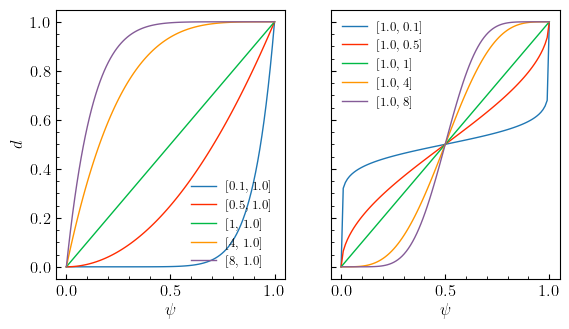

In [5]:
fig, axs = plt.subplots(1,2, figsize=(6.5,3.5),  sharey=True)

parameter_range = [0.1, 0.5, 1, 4, 8]
parameters = [None, None]

for i,ax in enumerate(axs):
    for param in parameter_range:
        parameters[i] = param
        parameters[not i] = 1.0
        a = accumulation.MBeta(parameters)
        ax.plot(psi, [a.getIndex(x).y for x in psi], label=f"{parameters}")
    
    ax.legend()
    # ax.axis("equal")
    ax.set_xlabel(r"$\psi$")
axs[0].set_ylabel(r"$d$");

In [6]:
#????????????????????????????????
# fig, axs = plt.subplots(1,2, figsize=(6.5,3.5),  sharey=True)

# parameter_range = [0.1, 0.5, 1, 4, 8]
# parameters = [None, None]

# for i,ax in enumerate(axs):
#     for param in parameter_range:
#         parameters[i] = param
#         parameters[not i] = 1.0
#         a = accumulation.Weibull(parameters)
#         ax.plot(psi, [a.getIndex(2*x).y for x in psi], label=f"{parameters}")
#     ax.legend()
#     # ax.axis("equal")
#     ax.set_xlabel(r"$\psi$")
# axs[0].set_ylabel(r"$d$");

### Dissipation

The `TotalStrain` dissipation rule specifies the maner in which energy is dissipated for a particular loading direction. This allows distinct strategies to be applied in tension and compression.

A directional dissipation rule can be defined in the following ways:

- `TotalStrain(accum, interval, cycle, scale)`




In [7]:
Fy  = 66.8*ksi             # steel yield stress
Es  = 29000.*ksi           # modulus of steel
Bs  = 0.04                 # strain-hardening ratio 
R0  = 20                   # control the transition from elastic to plastic branches
cR1 = 0.925                # "
cR2 = 0.15                 # "

In [8]:
steel = xara.UniaxialMaterial("Steel02", 60e3, 29e6, 0.05, R0=R0)

In [9]:
interval  = [3, 125]  # [Cd0, Cd1]
cycle     =  0.0   # Cwc
scale     = {"E": 29e6, "fy": 60e3}
# Directional Coupling
coupling  = [0.1, 0.1]    # Ccd

In [10]:
# a = accumulation.MBeta([4.2, 1.])
evol = ["mbeta", [4.2, 1.0]]
d = dissipation.TotalStrain(evol, interval, cycle, scale)
m = UniaxialDamage(steel,  d)

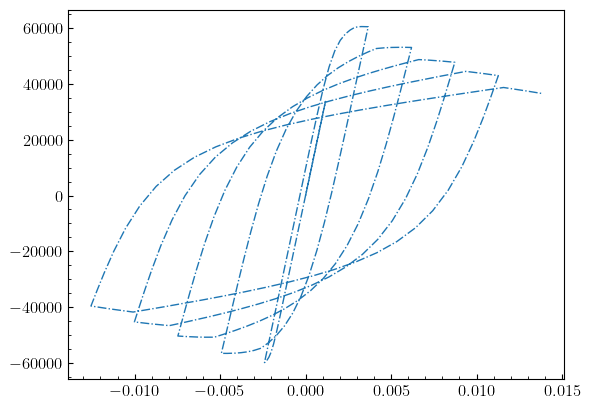

In [11]:
n = 300
strain = Fy/Es*sin(linspace(0, 10.5*pi, n))*linspace(0.2, 6.0, n)
with m as mat:
    plt.plot(strain, [mat.getStress(e, commit=True) for e in strain],"-.")

## Examples

In [12]:
a = accumulation.MBeta(1, [4.2, 1.])
d = dissipation.TotalStrain(evol, interval, cycle, scale)

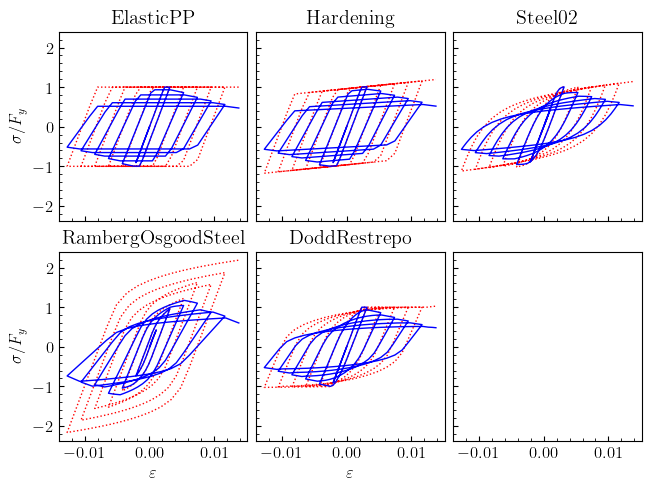

In [13]:
n = 300
strain = Fy/Es*sin(linspace(0, 12.5*pi, n))*linspace(0.2, 6.0, n)

fig, ax = plt.subplots(2,3, sharey=True, sharex=True, constrained_layout=True)

esh, esu = 10*Fy/Es, 14*Fy/Es
eshi = (esu + 5*esh)/5

materials = [
    xara.UniaxialMaterial("ElasticPP", Es, Fy/Es),
    xara.UniaxialMaterial("Hardening", Es, Fy, 0.00*Es, 0.04*Es),
    xara.UniaxialMaterial("Steel02", Fy, Es, Bs, 18.),
    xara.UniaxialMaterial("RambergOsgoodSteel", Fy, Es, 0.002, 4),
    xara.UniaxialMaterial("DoddRestrepo", Fy, 1.3*Fy, esh, esu, Es, eshi, 1.1*Fy),
]

for i,base in enumerate(materials):
    with base as m:
        ax[i//3, i%3].plot(strain, 
                           [m.getStress(e, commit=True)/Fy for e in strain], ":", label="base", color="red")
        ax[i//3, i%3].set_title(base.type)

    with UniaxialDamage(base, d) as m:
        ax[i//3, i%3].plot(strain, [m.getStress(e, commit=True)/Fy for e in strain], color="blue")

    if not i%3:
        ax[i//3, i%3].set_ylabel(r"$\sigma/F_y$")

    if i//3:
        ax[i//3, i%3].set_xlabel(r"$\varepsilon$")

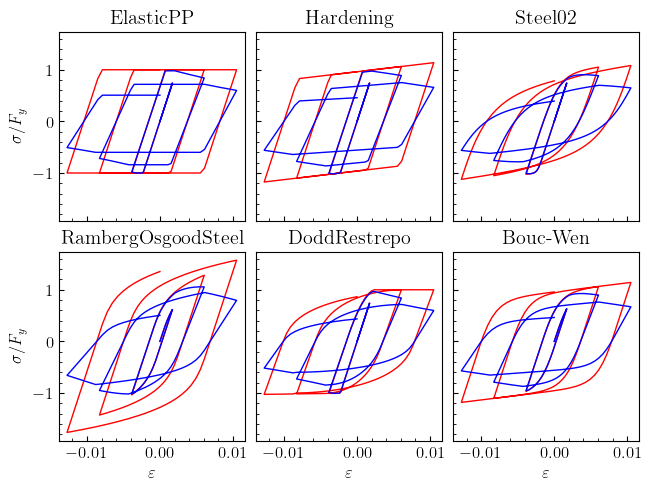

In [14]:
n = 300
strain = Fy/Es*sin(linspace(0, 6*pi, n))*linspace(0.2, 6.0, n)

fig, ax = plt.subplots(2,3, sharey=True, sharex=True, constrained_layout=True)

esh, esu = 10*Fy/Es, 14*Fy/Es
eshi = (esu + 5*esh)/5

materials = [
    xara.UniaxialMaterial("ElasticPP", Es, Fy/Es),
    xara.UniaxialMaterial("Hardening", Es, Fy, 0.00*Es, 0.04*Es),
    xara.UniaxialMaterial("Steel02", Fy, Es, Bs, 18.),
    xara.UniaxialMaterial("RambergOsgoodSteel", Fy, Es, 0.002, 4),
    xara.UniaxialMaterial("DoddRestrepo", Fy, 1.3*Fy, esh, esu, Es, eshi, 1.1*Fy),
    xara.UniaxialMaterial("BWBF", Fy=Fy, E=Es, alpha=0.04, n=2)
]

names = {"BWBF": "Bouc-Wen"}

for i,base in enumerate(materials):
    with base as m:
        ax[i//3, i%3].plot(strain, 
                           [m.getStress(e, commit=True)/Fy for e in strain], label="base", color="red")
        ax[i//3, i%3].set_title(names.get(base.type, base.type))

    with UniaxialDamage(base, d) as m:
        ax[i//3, i%3].plot(strain, [m.getStress(e, commit=True)/Fy for e in strain], color="blue")

    if not i%3:
        ax[i//3, i%3].set_ylabel(r"$\sigma/F_y$")

    if i//3:
        ax[i//3, i%3].set_xlabel(r"$\varepsilon$")